In [134]:
import keras
import numpy as np
from IPython.core.guarded_eval import dict_keys
from keras.datasets import imdb

(train_data, train_label), (test_data, test_label) = imdb.load_data(
    num_words=10000
)

### Decoding reviews back to text

1. ```word_index = imbd.get_word_index()``` is retrieving the dictionary which holds the key (word index) and the value (string word)
<br> 2. ```...get(i - 3, "?")...``` an offset of 3 because 3 spaces are required at the start of the sentence for <b>special tokens</b>: <br>0: padding, 1: start of sentence, 2: unknown.

In [135]:
word_index = imdb.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_review = " ".join(
    [reverse_word_index.get(i - 3, "?") for i in train_data[0]]
)

In [136]:
review = ""
for letter in decoded_review:
    if letter != "?":
        review += " ".join(letter)

In [137]:
review

" this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert  is an amazing actor and now the same being director  father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for  and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also  to the two little boy's that played the  of norman and paul they were just brilliant children are often left out of the  list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you think the

In [138]:
def multi_hot_encoding(sequences, num_classes):
    results = np.zeros(shape=(len(sequences), num_classes))
    for i, sequence in enumerate(sequences):
        results[i][sequence] = 1.0
    return results

### Convert data to tensors
This is where the dataset test and train are vectorized so that they can be passed as tabular data through the Dense layers
<br><br> _**Multi-hot encoding** is used to treat text data as tabular data (rows, columns) or (samples, features)._

In [139]:
x_train = multi_hot_encoding(train_data, num_classes=10000)
x_test = multi_hot_encoding(test_data, num_classes=10000)
y_train = train_label.astype("float32")
y_test = test_label.astype("float32")

In [142]:
model = keras.Sequential(
    [
        keras.layers.Dense(16, activation="relu"),
        keras.layers.Dense(16, activation="relu"),
        keras.layers.Dense(1, activation="sigmoid"), # outputs score 0 to 1 (probability)
    ]
)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
model.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8612 - loss: 0.3306 - val_accuracy: 0.8906 - val_loss: 0.2781
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9344 - loss: 0.1743 - val_accuracy: 0.8814 - val_loss: 0.3047
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9583 - loss: 0.1079 - val_accuracy: 0.8786 - val_loss: 0.3631
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9787 - loss: 0.0624 - val_accuracy: 0.8730 - val_loss: 0.4376
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9893 - loss: 0.0314 - val_accuracy: 0.8736 - val_loss: 0.5927
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9944 - loss: 0.0176 - val_accuracy: 0.8646 - val_loss: 0.6750
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9943 - loss: 0.0158 - val_accuracy: 0.8680 - val_loss: 0.7524
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9963 - loss: 0.0113 - val_accuracy: 0.

### Validation
When we do validation we use a part of the training data?
<br><br> 1. **Training data** (the data the model trains with to improve)
<br>2. **Validation data**
 (the data the model tests itself with during training)
<br>3. **Test data** (the data the model tests with (unseen data or the final test))

In [143]:
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=12,
    validation_split=0.2
)

Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 998us/step - accuracy: 0.9652 - loss: 0.1278 - val_accuracy: 0.8570 - val_loss: 0.4353
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 970us/step - accuracy: 0.9908 - loss: 0.0289 - val_accuracy: 0.8737 - val_loss: 0.6020
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9978 - loss: 0.0063 - val_accuracy: 0.8730 - val_loss: 0.7597
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 987us/step - accuracy: 0.9991 - loss: 0.0023 - val_accuracy: 0.8770 - val_loss: 0.8483
Epoch 5/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 990us/step - accuracy: 0.9997 - loss: 0.0012 - val_accuracy: 0.8773 - val_loss: 0.9956
Epoch 6/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9998 - loss: 8.0801e-04 - val_accuracy: 0.8773 - val_loss: 1.0662
Epoch 7/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9998 - loss: 5.6871e-04 - val_accuracy: 0.8773 - val_loss: 1.1561
Epoch 8/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 1.0000 -

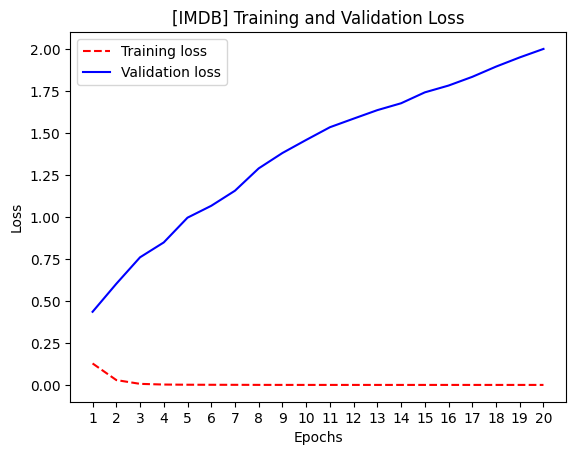

In [144]:
import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "r--", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("[IMDB] Training and Validation Loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

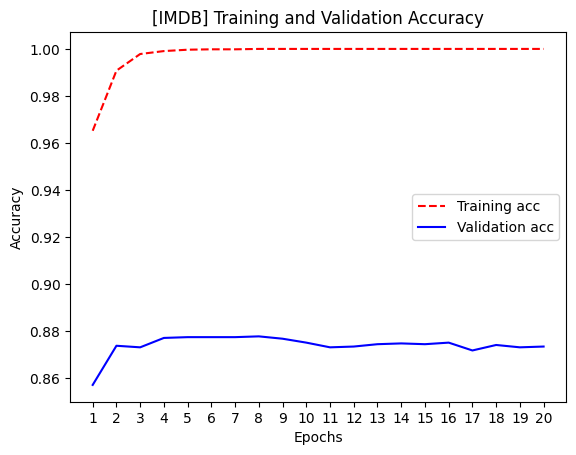

In [145]:
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("[IMDB] Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

**Overfitting has occurred here** - after the fourth epoch we can see that it seems to peak. The model continues to train beyond that point of optimal generalization causing overfitting, where the model memorizes the data instead of learning general patterns.

### Reworked model
. using only 4 epochs in a model

In [147]:
model = keras.Sequential(
    [
        keras.layers.Dense(16, activation="relu"),
        keras.layers.Dense(16, activation="relu"),
        keras.layers.Dense(1, activation="sigmoid"),
    ]
)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.fit(
    x_train,
    y_train,
    epochs=4,
    batch_size=512,
    validation_split=0.2,
)

Epoch 1/4
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7799 - loss: 0.5207 - val_accuracy: 0.8726 - val_loss: 0.3608
Epoch 2/4
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9035 - loss: 0.2776 - val_accuracy: 0.8896 - val_loss: 0.2848
Epoch 3/4
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9317 - loss: 0.1965 - val_accuracy: 0.8920 - val_loss: 0.2734
Epoch 4/4
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9481 - loss: 0.1536 - val_accuracy: 0.8910 - val_loss: 0.2832


In [148]:
results = model.evaluate(x_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 488us/step - accuracy: 0.8818 - loss: 0.3021


In [150]:
results
# test loss and test accuracy

[0.3020908236503601, 0.8817999958992004]

This **approach is naive** as it achieves an accuracy of 88%, we should be able to get close to 95%.

### Model predictions on test data

In [151]:
model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 373us/step


array([[0.2295995 ],
       [0.99989235],
       [0.3519323 ],
       ...,
       [0.06305383],
       [0.08935623],
       [0.4221911 ]], shape=(25000, 1), dtype=float32)

Some samples the model is confident with an accuracy of 99% whereas some is less confident with 55% etc.

## Further experiments

### Using three layers in a model

In [160]:
model = keras.Sequential(
    [
        keras.layers.Dense(16, activation="relu"),
        keras.layers.Dense(16, activation="relu"),
        keras.layers.Dense(16, activation="relu"),
        keras.layers.Dense(1, activation="sigmoid"),
    ]
)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(x_train, y_train, epochs=20, batch_size=512, validation_split=0.2)
model.evaluate(x_test, y_test)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7534 - loss: 0.5879 - val_accuracy: 0.8640 - val_loss: 0.4140
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8941 - loss: 0.3040 - val_accuracy: 0.8900 - val_loss: 0.2802
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9315 - loss: 0.1931 - val_accuracy: 0.8858 - val_loss: 0.2829
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9474 - loss: 0.1484 - val_accuracy: 0.8898 - val_loss: 0.2925
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9632 - loss: 0.1132 - val_accuracy: 0.8852 - val_loss: 0.3262
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9720 - loss: 0.0903 - val_accuracy: 0.8808 - val_loss: 0.3732
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9782 - loss: 0.0739 - val_accuracy: 0.8796 - val_loss: 0.3946
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9859 - loss: 0.0552 - val_accuracy: 0.8756 - val_loss

[0.9715680480003357, 0.8554400205612183]

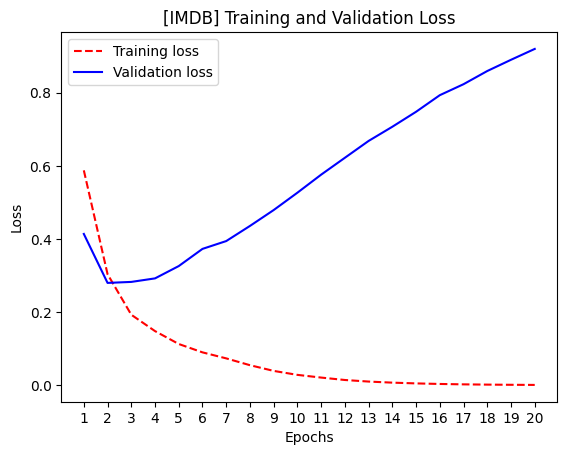

In [161]:
history_dict = history.history
model_history = model.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "r--", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("[IMDB] Training and Validation Loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

1. 2 epochs is now the optimal number of repeats
2. Also after 3 overfitting is visible - training loss is falling while the validation loss increases.

In [166]:
model = keras.Sequential(
    [
        keras.layers.Dense(16, activation="relu"),
        keras.layers.Dense(16, activation="relu"),
        keras.layers.Dense(16, activation="relu"),
        keras.layers.Dense(1, activation="sigmoid"),
    ]
)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(x_train, y_train, epochs=2, batch_size=512, validation_split=0.2)
model.evaluate(x_test, y_test)

Epoch 1/2
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7692 - loss: 0.5774 - val_accuracy: 0.8686 - val_loss: 0.4028
Epoch 2/2
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8992 - loss: 0.2893 - val_accuracy: 0.8906 - val_loss: 0.2783
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 473us/step - accuracy: 0.8854 - loss: 0.2900


[0.290025532245636, 0.8854399919509888]

In [167]:
model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 381us/step


array([[0.28422666],
       [0.9988304 ],
       [0.80667746],
       ...,
       [0.12197557],
       [0.14825226],
       [0.43758485]], shape=(25000, 1), dtype=float32)

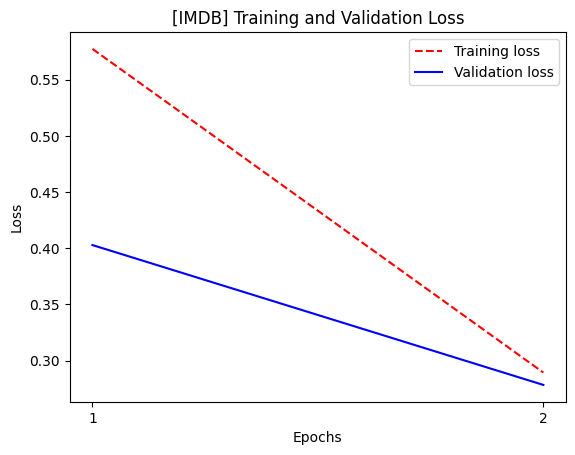

In [168]:
history_dict = history.history
model_history = model.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "r--", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("[IMDB] Training and Validation Loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

88% is the ceiling for this approach - to increase we would have to use other techniques: embedding, transformers etc